# NIVEL AVANZADO - Calidad de Datos con POO

Este notebook implementa un sistema de calidad de datos usando programación orientada a objetos aplicado al archivo `SISMEPRE_CAPA_SILVER.csv`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from typing import Dict, List, Tuple, Any
from dataclasses import dataclass
import re
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## Clases Base del Sistema

In [2]:
@dataclass
class ResultadoCalidad:
    """
    Clase para almacenar resultados de análisis de calidad.
    
    Attributes:
        dimension (str): Nombre de la dimensión de calidad evaluada
        registros_problematicos (pd.DataFrame): DataFrame con registros que tienen problemas
        total_registros (int): Total de registros en el dataset
        descripcion (str): Descripción del problema encontrado
        severidad (str): Nivel de severidad (ALTA, MEDIA, BAJA)
    """
    dimension: str
    registros_problematicos: pd.DataFrame
    total_registros: int
    descripcion: str = ""
    severidad: str = "MEDIA"
    
    @property
    def cantidad_problemas(self) -> int:
        """Retorna la cantidad de registros con problemas"""
        return len(self.registros_problematicos)
    
    @property
    def porcentaje_afectado(self) -> float:
        """Calcula el porcentaje de registros afectados"""
        if self.total_registros == 0:
            return 0.0
        return (self.cantidad_problemas / self.total_registros) * 100
    
    def resumen(self) -> Dict[str, Any]:
        """
        Genera un resumen del resultado.
        
        Returns:
            dict: Diccionario con métricas clave
        """
        return {
            'dimensión': self.dimension,
            'problemas': self.cantidad_problemas,
            'porcentaje': round(self.porcentaje_afectado, 2),
            'severidad': self.severidad
        }

In [3]:
class AnalizadorCalidadBase:
    """
    Clase base abstracta para analizadores de calidad de datos.
    
    Esta clase define la interfaz que deben implementar todos los analizadores
    de dimensiones específicas de calidad.
    
    Attributes:
        df (pd.DataFrame): DataFrame a analizar
        nombre_dimension (str): Nombre de la dimensión de calidad
    """
    
    def __init__(self, df: pd.DataFrame, nombre_dimension: str):
        """
        Inicializa el analizador.
        
        Args:
            df: DataFrame de pandas con los datos a analizar
            nombre_dimension: Nombre identificador de la dimensión
        """
        self.df = df
        self.nombre_dimension = nombre_dimension
        self.resultados = []
    
    def analizar(self) -> List[ResultadoCalidad]:
        """
        Método abstracto que debe implementar cada analizador.
        
        Returns:
            Lista de ResultadoCalidad con los problemas encontrados
        """
        raise NotImplementedError("Subclases deben implementar este método")
    
    def _crear_resultado(self, registros: pd.DataFrame, descripcion: str, 
                        severidad: str = "MEDIA") -> ResultadoCalidad:
        """
        Crea un objeto ResultadoCalidad.
        
        Args:
            registros: DataFrame con registros problemáticos
            descripcion: Descripción del problema
            severidad: Nivel de severidad del problema
        
        Returns:
            Objeto ResultadoCalidad configurado
        """
        return ResultadoCalidad(
            dimension=self.nombre_dimension,
            registros_problematicos=registros,
            total_registros=len(self.df),
            descripcion=descripcion,
            severidad=severidad
        )

## Analizadores Específicos por Dimensión

In [4]:
class AnalizadorCompletitud(AnalizadorCalidadBase):
    """
    Analiza la completitud de los datos (valores faltantes).
    
    La completitud mide si todos los campos requeridos tienen valores.
    Identifica columnas con valores NULL o vacíos.
    """
    
    def __init__(self, df: pd.DataFrame):
        super().__init__(df, "Completitud")
    
    def analizar(self) -> List[ResultadoCalidad]:
        """
        Ejecuta el análisis de completitud.
        
        Identifica todas las columnas con valores faltantes y crea
        un resultado por cada columna afectada.
        
        Returns:
            Lista de ResultadoCalidad, uno por cada columna con faltantes
        """
        resultados = []
        
        for columna in self.df.columns:
            faltantes = self.df[self.df[columna].isnull()]
            if len(faltantes) > 0:
                severidad = self._determinar_severidad(len(faltantes))
                resultado = self._crear_resultado(
                    registros=faltantes,
                    descripcion=f"Valores faltantes en columna '{columna}'",
                    severidad=severidad
                )
                resultados.append(resultado)
        
        return resultados
    
    def _determinar_severidad(self, cantidad: int) -> str:
        """
        Determina la severidad basándose en la cantidad de faltantes.
        
        Args:
            cantidad: Número de registros faltantes
        
        Returns:
            'ALTA', 'MEDIA' o 'BAJA'
        """
        porcentaje = (cantidad / len(self.df)) * 100
        if porcentaje > 10:
            return "ALTA"
        elif porcentaje > 5:
            return "MEDIA"
        return "BAJA"

In [5]:
class AnalizadorExactitud(AnalizadorCalidadBase):
    """
    Analiza la exactitud de valores numéricos.

    Detecta valores que son matemáticamente incorrectos o imposibles
    para el contexto del archivo SISMEPRE_CAPA_SILVER.csv, como meses
    fuera del rango calendario o identificadores no positivos.
    """

    def __init__(self, df: pd.DataFrame):
        super().__init__(df, "Exactitud")

    def analizar(self) -> List[ResultadoCalidad]:
        """
        Ejecuta validaciones de exactitud numérica.

        Verifica:
        - Mes estadístico fuera del rango 1-12
        - Años estadísticos posteriores al año de aplicación
        - Identificadores numéricos no positivos
        - Respuestas numéricas negativas

        Returns:
            Lista de ResultadoCalidad con los problemas detectados
        """
        resultados = []

        # Mes estadístico fuera del rango calendario
        meses_invalidos = self.df[~self.df['MES_ESTADISTICA'].between(1, 12)]
        if len(meses_invalidos) > 0:
            resultados.append(self._crear_resultado(
                meses_invalidos, "Mes estadístico fuera del rango 1-12", "ALTA"
            ))

        # Año estadístico posterior al año de aplicación
        anios_invalidos = self.df[self.df['ANO_ESTADISTICA'] > self.df['ANO_APLICACION']]
        if len(anios_invalidos) > 0:
            resultados.append(self._crear_resultado(
                anios_invalidos, "Año estadístico posterior al año de aplicación", "MEDIA"
            ))

        # Identificadores no positivos
        columnas_id = ['SEC_EJEC', 'FORMULARIO_ID', 'PREGUNTA_ID', 'RESPUESTA_ID']
        for columna in columnas_id:
            ids_invalidos = self.df[self.df[columna] <= 0]
            if len(ids_invalidos) > 0:
                resultados.append(self._crear_resultado(
                    ids_invalidos, f"Identificadores no positivos en '{columna}'", "ALTA"
                ))

        # Respuestas numéricas negativas
        columnas_respuesta = ['RESPUESTA_DECIMAL', 'RESPUESTA_ENTERO']
        for columna in columnas_respuesta:
            negativos = self.df[self.df[columna] < 0]
            if len(negativos) > 0:
                resultados.append(self._crear_resultado(
                    negativos, f"Valores negativos en '{columna}'", "MEDIA"
                ))

        return resultados

In [6]:
class GestorCalidadDatos:
    """
    Clase principal que coordina todos los análisis de calidad.
    
    Esta clase actúa como fachada para ejecutar y consolidar
    los resultados de todos los analizadores de dimensiones.
    
    Attributes:
        df (pd.DataFrame): Dataset a analizar
        analizadores (List): Lista de analizadores configurados
        resultados_globales (Dict): Resultados consolidados de todos los análisis
    """
    
    def __init__(self, df: pd.DataFrame):
        """
        Inicializa el gestor con el dataset.
        
        Args:
            df: DataFrame de pandas con los datos a analizar
        """
        self.df = df
        self.analizadores = []
        self.resultados_globales = {}
    
    def registrar_analizador(self, analizador: AnalizadorCalidadBase) -> None:
        """
        Registra un nuevo analizador en el sistema.
        
        Args:
            analizador: Instancia de un analizador de calidad
        """
        self.analizadores.append(analizador)
    
    def ejecutar_analisis_completo(self) -> Dict[str, List[ResultadoCalidad]]:
        """
        Ejecuta todos los analizadores registrados.
        
        Itera sobre cada analizador, ejecuta su análisis y almacena
        los resultados organizados por dimensión.
        
        Returns:
            Diccionario con resultados agrupados por dimensión
        """
        for analizador in self.analizadores:
            dimension = analizador.nombre_dimension
            resultados = analizador.analizar()
            self.resultados_globales[dimension] = resultados
        
        return self.resultados_globales
    
    def generar_reporte_consolidado(self) -> pd.DataFrame:
        """
        Genera un reporte consolidado de todas las dimensiones.
        
        Agrupa los resultados de todos los analizadores en un
        DataFrame con métricas resumen.
        
        Returns:
            DataFrame con resumen ejecutivo de calidad
        """
        datos_reporte = []
        
        for dimension, resultados in self.resultados_globales.items():
            total_problemas = sum(r.cantidad_problemas for r in resultados)
            porcentaje = (total_problemas / len(self.df)) * 100 if len(self.df) > 0 else 0
            
            datos_reporte.append({
                'Dimensión': dimension,
                'Registros Afectados': total_problemas,
                'Porcentaje': round(porcentaje, 2),
                'Tipos de Problemas': len(resultados)
            })
        
        return pd.DataFrame(datos_reporte)
    
    def visualizar_resultados(self) -> None:
        """
        Genera visualizaciones de los resultados de calidad.
        
        Crea gráficos de barras mostrando el porcentaje de registros
        afectados por dimensión.
        """
        reporte = self.generar_reporte_consolidado()
        
        plt.figure(figsize=(12, 6))
        plt.barh(reporte['Dimensión'], reporte['Porcentaje'], color='steelblue')
        plt.xlabel('Porcentaje de Registros Afectados (%)', fontsize=12)
        plt.title('Problemas de Calidad por Dimensión', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

## Ejecución del Sistema de Calidad

In [7]:
# Cargar datos
df = pd.read_csv(
    'SISMEPRE_CAPA_SILVER.csv',
    na_values=[' ', ''],
    keep_default_na=True
)

print(f"Dataset cargado: {len(df):,} registros")
print(f"Columnas disponibles: {len(df.columns)}")
print(df.columns.tolist())

# Crear gestor principal
gestor = GestorCalidadDatos(df)

# Registrar analizadores
gestor.registrar_analizador(AnalizadorCompletitud(df))
gestor.registrar_analizador(AnalizadorExactitud(df))


Dataset cargado: 100,000 registros
Columnas disponibles: 27
['SEC_EJEC', 'ANO_APLICACION', 'USUARIO_CREACION_FECHA', 'ESTADO', 'USUARIO_ENVIO_ID', 'USUARIO_FECHA_ENVIO', 'CORREO', 'ORIGEN_INFORMACION', 'CLASIFICACION', 'PERIODO', 'TIPO_META', 'IND_RESOL_ALCAL_ADJUNTO', 'FECHA_RESOL_ALCAL_ADJUNTO', 'FORMULARIO_ID', 'ANO_ESTADISTICA', 'MES_ESTADISTICA', 'ESTADO_REGISTRO', 'ANO_ESTADISTICA_DESC', 'SEC_EJEC_1', 'FORMULARIO_ID_1', 'PREGUNTA_ID', 'RESPUESTA_ID', 'RESPUESTA_TEXTO', 'RESPUESTA_DECIMAL', 'RESPUESTA_ENTERO', 'RESPUESTA_FECHA', 'ESTADO_REGISTRO_1']


In [8]:
# Ejecutar análisis completo
resultados = gestor.ejecutar_analisis_completo()
print("Análisis completado")

# Mostrar resultados detallados
for dimension, lista_resultados in resultados.items():
    print(f"DIMENSIÓN: {dimension}")
    for resultado in lista_resultados:
        print(f"  • {resultado.descripcion}")
        print(f"    Registros: {resultado.cantidad_problemas:,} ({resultado.porcentaje_afectado:.2f}%)")
        print(f"    Severidad: {resultado.severidad}")
        print()

Análisis completado
DIMENSIÓN: Completitud
  • Valores faltantes en columna 'USUARIO_FECHA_ENVIO'
    Registros: 100,000 (100.00%)
    Severidad: ALTA

  • Valores faltantes en columna 'CORREO'
    Registros: 100,000 (100.00%)
    Severidad: ALTA

  • Valores faltantes en columna 'RESPUESTA_FECHA'
    Registros: 99,575 (99.58%)
    Severidad: ALTA

DIMENSIÓN: Exactitud
  • Mes estadístico fuera del rango 1-12
    Registros: 100,000 (100.00%)
    Severidad: ALTA



REPORTE CONSOLIDADO DE CALIDAD
  Dimensión  Registros Afectados  Porcentaje  Tipos de Problemas
Completitud               299575      299.57                   3
  Exactitud               100000      100.00                   1


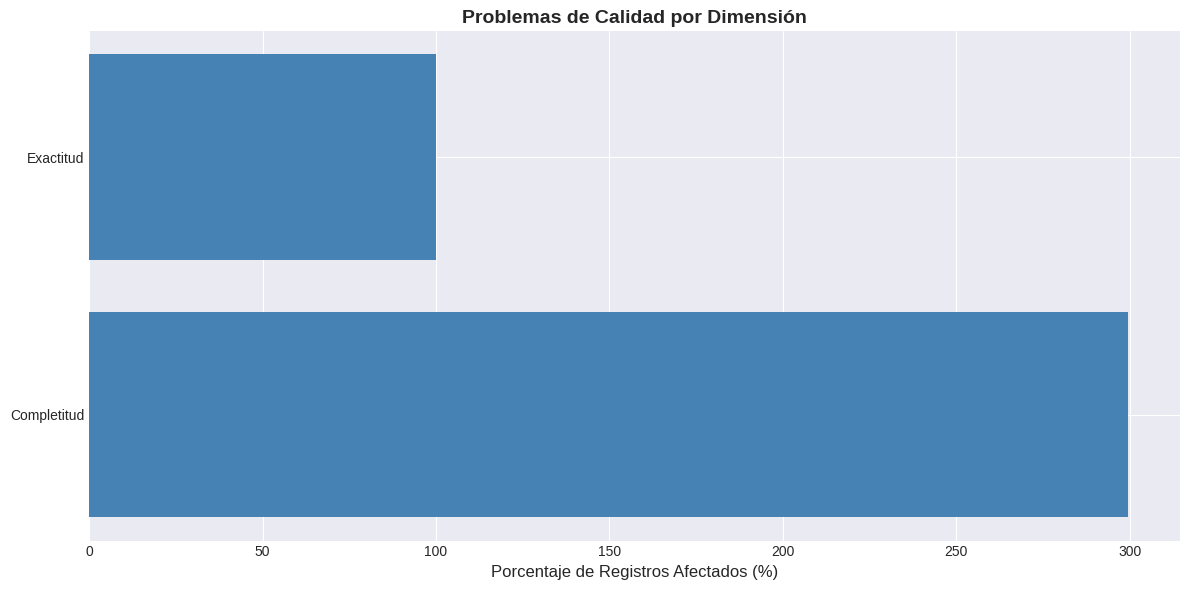

In [9]:
# Generar reporte consolidado
reporte = gestor.generar_reporte_consolidado()

print("REPORTE CONSOLIDADO DE CALIDAD")
print(reporte.to_string(index=False))

# Visualizar resultados
gestor.visualizar_resultados()

## Análisis Detallado por Dimensión

El sistema permite acceder a los registros problemáticos específicos:

In [10]:
# Ejemplo: Ver registros con problemas de exactitud
if 'Exactitud' in resultados:
    print("Ejemplos de problemas de EXACTITUD:\n")
    columnas_muestra = [
        'SEC_EJEC', 'ANO_APLICACION', 'ANO_ESTADISTICA',
        'MES_ESTADISTICA', 'FORMULARIO_ID', 'PREGUNTA_ID',
        'RESPUESTA_ID', 'RESPUESTA_TEXTO', 'RESPUESTA_DECIMAL',
        'RESPUESTA_ENTERO'
    ]
    columnas_muestra = [col for col in columnas_muestra if col in df.columns]

    for resultado in resultados['Exactitud']:
        print(f"\n{resultado.descripcion}:")
        print(resultado.registros_problematicos.head()[columnas_muestra])


Ejemplos de problemas de EXACTITUD:


Mes estadístico fuera del rango 1-12:
   SEC_EJEC  ANO_APLICACION  ...  RESPUESTA_DECIMAL  RESPUESTA_ENTERO
0    301003            2022  ...                0.0                 0
1    301046            2022  ...                0.0                 0
2    301052            2022  ...                0.0                 0
3    301090            2022  ...                0.0                 0
4    301098            2022  ...                0.0                 0

[5 rows x 10 columns]
